# ProductMeasure: Combining Independent True Measures

## Motivation

Sometimes an integrand naturally uses independent components from different true measures. `ProductMeasure` combines those components side by side.

If the marginal dimensions are $d_1, \ldots, d_k$, then the total ProductMeasure dimension is

$$
d = d_1 + \cdots + d_k.
$$

A single outer sampler generates points in $[0,1]^d$. `ProductMeasure` splits each point along the final coordinate axis, sends each block to the corresponding marginal transform, and concatenates the transformed blocks.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

from qmcpy.discrete_distribution import DigitalNetB2, DummySampler
from qmcpy.true_measure import Gaussian, ProductMeasure, SciPyWrapper, Uniform, ZeroInflatedExpUniform
from qmcpy.util import DimensionError, ParameterError

# ZeroInflatedExpUniform is a transform-focused custom marginal without a PDF.
# This demo validates generated samples, not density weights for that marginal.
warnings.filterwarnings(
    "ignore",
    message="Custom univariate distribution has no 'pdf' or 'logpdf'.*",
    category=UserWarning,
)

np.set_printoptions(precision=6, suppress=True)

## Important note on marginal samplers

QMCPy currently requires every true measure to be constructed with a discrete distribution. In this notebook, `DummySampler` is used only to satisfy that construction requirement for ProductMeasure marginals.

`DummySampler` generates no sample points. The only sampler that controls ProductMeasure sampling is the **outer sampler** passed directly to `ProductMeasure`.

Replications also belong to the outer sampler. Marginal `DummySampler` objects do not need matching replications.

## Example 1: Basic ProductMeasure

**What is being tested?** We combine two one-dimensional marginals: `Uniform(0, 2)` and `Uniform(10, 12)`.

**Expected result.** The output should have shape `(n, 2)`, the first coordinate should stay inside `[0, 2]`, the second coordinate should stay inside `[10, 12]`, and the sample means should be close to the theoretical means `1` and `11`.

**Why it matters.** This is the core ProductMeasure behavior: one two-dimensional outer QMC point is split into two one-dimensional coordinate blocks and transformed by the two marginals.

Expected sample shape: (256, 2)
Actual sample shape: (256, 2)

Marginal 1: Uniform(0, 2)
  Observed range: [0.000709, 1.994566]
  Observed mean: 1.000000
  Theoretical mean: 1.000000
  Absolute mean error: 0.000e+00

Marginal 2: Uniform(10, 12)
  Observed range: [10.000635, 11.994399]
  Observed mean: 11.000000
  Theoretical mean: 11.000000
  Absolute mean error: 3.553e-15


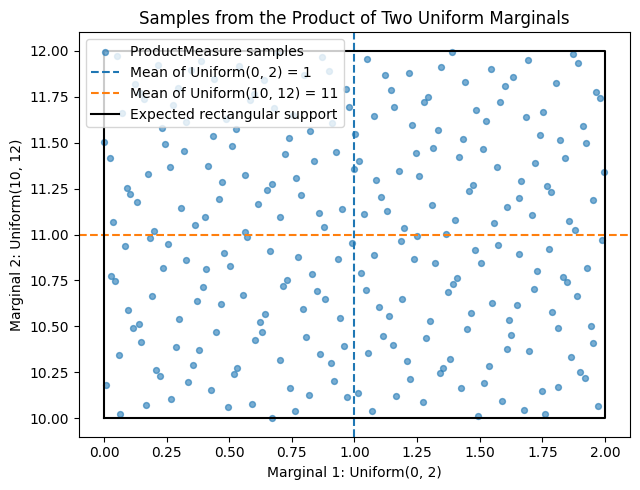

In [2]:
n = 256
marginals = [
    Uniform(DummySampler(1), lower_bound=0.0, upper_bound=2.0),
    Uniform(DummySampler(1), lower_bound=10.0, upper_bound=12.0),
]
outer_sampler = DigitalNetB2(2, seed=7)
product_measure = ProductMeasure(sampler=outer_sampler, marginals=marginals)

samples = product_measure(n)
expected_shape = (n, 2)
expected_means = np.array([1.0, 11.0])
observed_means = samples.mean(axis=0)

print("Expected sample shape:", expected_shape)
print("Actual sample shape:", samples.shape)
print()
print("Marginal 1: Uniform(0, 2)")
print(f"  Observed range: [{samples[:, 0].min():.6f}, {samples[:, 0].max():.6f}]")
print(f"  Observed mean: {observed_means[0]:.6f}")
print(f"  Theoretical mean: {expected_means[0]:.6f}")
print(f"  Absolute mean error: {abs(observed_means[0] - expected_means[0]):.3e}")
print()
print("Marginal 2: Uniform(10, 12)")
print(f"  Observed range: [{samples[:, 1].min():.6f}, {samples[:, 1].max():.6f}]")
print(f"  Observed mean: {observed_means[1]:.6f}")
print(f"  Theoretical mean: {expected_means[1]:.6f}")
print(f"  Absolute mean error: {abs(observed_means[1] - expected_means[1]):.3e}")

assert samples.shape == expected_shape
assert np.all((0.0 <= samples[:, 0]) & (samples[:, 0] <= 2.0))
assert np.all((10.0 <= samples[:, 1]) & (samples[:, 1] <= 12.0))

fig, ax = plt.subplots(figsize=(6.5, 5.0))
ax.scatter(samples[:, 0], samples[:, 1], s=18, alpha=0.6, label="ProductMeasure samples")
ax.axvline(expected_means[0], color="C0", linestyle="--", linewidth=1.5, label="Mean of Uniform(0, 2) = 1")
ax.axhline(expected_means[1], color="C1", linestyle="--", linewidth=1.5, label="Mean of Uniform(10, 12) = 11")
ax.plot([0, 2, 2, 0, 0], [10, 10, 12, 12, 10], color="black", linewidth=1.5, label="Expected rectangular support")
ax.set_xlabel("Marginal 1: Uniform(0, 2)")
ax.set_ylabel("Marginal 2: Uniform(10, 12)")
ax.set_title("Samples from the Product of Two Uniform Marginals")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The shape, ranges, and theoretical mean checks confirm that the two-dimensional outer sampler was split into two one-dimensional blocks and transformed into the intended product of uniform marginals.

## Example 2: Replications

**What is being tested?** We use the same two uniform marginals, but the outer sampler now has three randomized replications.

**Expected result.** The output shape should be `(replications, n, total_dimension)`, here `(3, n, 2)`. Each replication should have sample means close to `1` and `11`.

**Why it matters.** This verifies that replications belong to the outer sampler and are preserved by `ProductMeasure` without needing replicated `DummySampler` marginals.

Number of replications: 3
Samples per replication: 1024
Total product dimension: 2
Expected output shape: (3, 1024, 2)
Actual output shape: (3, 1024, 2)

Replication    Mean of U(0,2)    Error from 1    Mean of U(10,12)    Error from 11
          1          1.000000      -1.110e-16            10.999999       -9.537e-07
          2          1.000000       0.000e+00            11.000000        8.882e-15
          3          1.000000       0.000e+00            11.000000       -3.553e-15


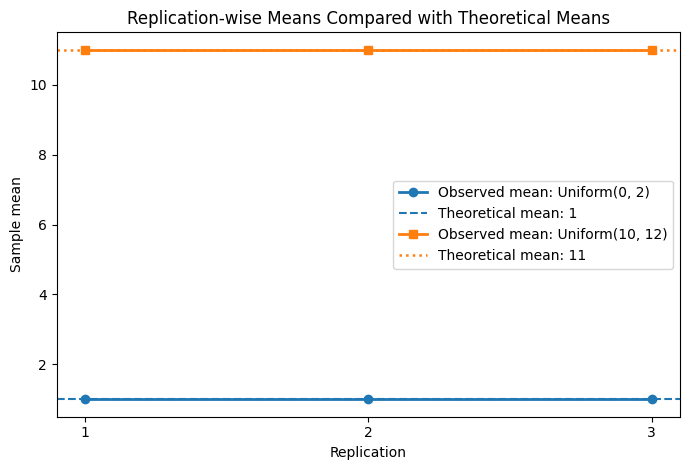

In [3]:
n = 1024
replications = 3
marginals = [
    Uniform(DummySampler(1), lower_bound=0.0, upper_bound=2.0),
    Uniform(DummySampler(1), lower_bound=10.0, upper_bound=12.0),
]
outer_sampler = DigitalNetB2(2, seed=13, replications=replications)
product_measure = ProductMeasure(sampler=outer_sampler, marginals=marginals)

samples = product_measure(n)
expected_shape = (outer_sampler.replications, n, product_measure.d)
replication_means = samples.mean(axis=1)
errors = replication_means - np.array([1.0, 11.0])

print("Number of replications:", outer_sampler.replications)
print("Samples per replication:", n)
print("Total product dimension:", product_measure.d)
print("Expected output shape:", expected_shape)
print("Actual output shape:", samples.shape)
print()
print("Replication    Mean of U(0,2)    Error from 1    Mean of U(10,12)    Error from 11")
for i, (means, errs) in enumerate(zip(replication_means, errors), start=1):
    print(f"{i:>11}    {means[0]:>14.6f}    {errs[0]:>12.3e}    {means[1]:>17.6f}    {errs[1]:>13.3e}")

assert samples.shape == expected_shape
assert np.allclose(replication_means[:, 0], 1.0, atol=0.03)
assert np.allclose(replication_means[:, 1], 11.0, atol=0.03)

x_axis = np.arange(1, outer_sampler.replications + 1)
fig, ax = plt.subplots(figsize=(7.0, 4.8))
ax.plot(x_axis, replication_means[:, 0], marker="o", linewidth=2, label="Observed mean: Uniform(0, 2)")
ax.axhline(1.0, color="C0", linestyle="--", linewidth=1.5, label="Theoretical mean: 1")
ax.plot(x_axis, replication_means[:, 1], marker="s", linewidth=2, label="Observed mean: Uniform(10, 12)")
ax.axhline(11.0, color="C1", linestyle=":", linewidth=1.8, label="Theoretical mean: 11")
ax.set_xticks(x_axis)
ax.set_xlabel("Replication")
ax.set_ylabel("Sample mean")
ax.set_title("Replication-wise Means Compared with Theoretical Means")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The small differences across replications come from independent randomizations of the outer sampler. The closeness to `1` and `11` confirms that each replication targets the same product distribution.

## Example 3: Multidimensional and zero-inflated marginals

**What is being tested?** We combine a two-dimensional Gaussian marginal with a one-dimensional zero-inflated exponential marginal.

**Expected result.** The total dimension should be `3`. The first two output columns should form the Gaussian block, and the third output column should contain nonnegative zero-inflated values with an observed zero proportion close to `p_zero`.

**Why it matters.** This shows that a ProductMeasure marginal may itself be multidimensional, while another marginal can be mixed/discrete-continuous through its inverse-CDF transform.

`ZeroInflatedExpUniform` supplies a sampling transform but not a density. This example validates the transformed samples and zero mass, not ProductMeasure density weights for that marginal.

Gaussian marginal dimension: 2
Zero-inflated marginal dimension: 1
Expected total dimension: 3
Actual ProductMeasure dimension: 3
Full sample shape: (2048, 3)
Gaussian block shape: (2048, 2)
Zero-inflated block shape: (2048, 1)
Specified zero probability: 0.4000
Observed zero proportion: 0.3999
Absolute zero-proportion error: 0.0001
Target Gaussian correlation: 0.6000
Observed Gaussian correlation: 0.5998


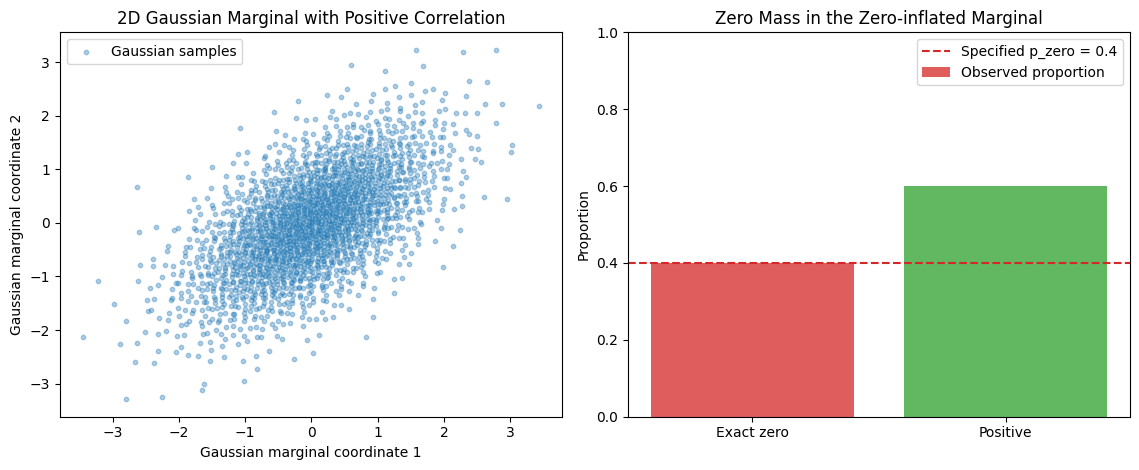

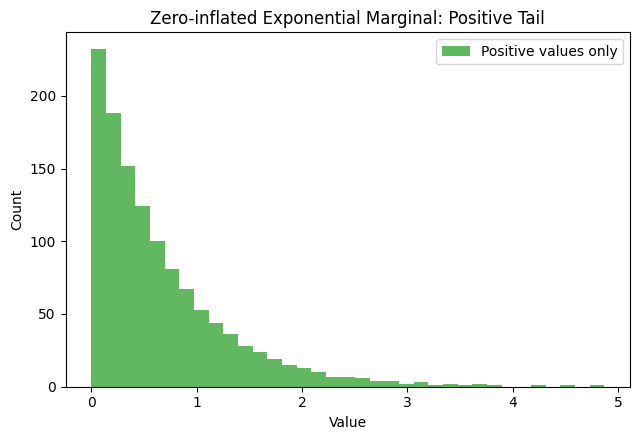

In [4]:
n = 2048
p_zero = 0.4
gaussian = Gaussian(
    DummySampler(2),
    mean=[0.0, 0.0],
    covariance=[[1.0, 0.6], [0.6, 1.0]],
)
zero_inflated = ZeroInflatedExpUniform(DummySampler(1), p_zero=p_zero, lam=1.5)
marginals = [gaussian, zero_inflated]
outer_sampler = DigitalNetB2(3, seed=31)
product_measure = ProductMeasure(sampler=outer_sampler, marginals=marginals)

samples = product_measure(n)
gaussian_samples = samples[:, : gaussian.d]
zero_inflated_samples = samples[:, gaussian.d :]
observed_zero_rate = np.mean(zero_inflated_samples[:, 0] == 0.0)
observed_corr = np.corrcoef(gaussian_samples.T)[0, 1]

print("Gaussian marginal dimension:", gaussian.d)
print("Zero-inflated marginal dimension:", zero_inflated.d)
print("Expected total dimension:", gaussian.d + zero_inflated.d)
print("Actual ProductMeasure dimension:", product_measure.d)
print("Full sample shape:", samples.shape)
print("Gaussian block shape:", gaussian_samples.shape)
print("Zero-inflated block shape:", zero_inflated_samples.shape)
print(f"Specified zero probability: {p_zero:.4f}")
print(f"Observed zero proportion: {observed_zero_rate:.4f}")
print(f"Absolute zero-proportion error: {abs(observed_zero_rate - p_zero):.4f}")
print(f"Target Gaussian correlation: 0.6000")
print(f"Observed Gaussian correlation: {observed_corr:.4f}")

assert product_measure.d == gaussian.d + zero_inflated.d
assert samples.shape == (n, 3)
assert gaussian_samples.shape == (n, 2)
assert zero_inflated_samples.shape == (n, 1)
assert np.all(zero_inflated_samples >= 0.0)
assert abs(observed_zero_rate - p_zero) < 0.05

positive_values = zero_inflated_samples[zero_inflated_samples[:, 0] > 0.0, 0]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))

axes[0].scatter(gaussian_samples[:, 0], gaussian_samples[:, 1], s=10, alpha=0.35, label="Gaussian samples")
axes[0].set_xlabel("Gaussian marginal coordinate 1")
axes[0].set_ylabel("Gaussian marginal coordinate 2")
axes[0].set_title("2D Gaussian Marginal with Positive Correlation")
axes[0].legend(loc="best")

axes[1].bar(["Exact zero", "Positive"], [observed_zero_rate, 1.0 - observed_zero_rate], color=["C3", "C2"], alpha=0.75, label="Observed proportion")
axes[1].axhline(p_zero, color="C3", linestyle="--", linewidth=1.5, label=f"Specified p_zero = {p_zero:.1f}")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Proportion")
axes[1].set_title("Zero Mass in the Zero-inflated Marginal")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.hist(positive_values, bins=35, alpha=0.75, color="C2", label="Positive values only")
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title("Zero-inflated Exponential Marginal: Positive Tail")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The dimension and block-shape checks show that `ProductMeasure` split the three-dimensional outer samples into a 2D Gaussian block and a 1D zero-inflated block. The zero proportion is close to the specified `p_zero`, and the Gaussian scatter reflects the positive target correlation.

## Example 4: DummySampler verification

**What is being tested?** We directly sample from `DummySampler`, then compare ProductMeasure outputs with identical and different outer sampler seeds.

**Expected result.** `DummySampler` should return an empty array. ProductMeasure objects with the same outer sampler seed should produce identical samples, while changing the outer sampler seed should change the samples.

**Why it matters.** This makes it explicit that marginal `DummySampler` objects are construction placeholders and do not control ProductMeasure sample generation.

In [5]:
requested_points = 4
dummy_samples = DummySampler(1).gen_samples(requested_points)

print("Requested number of points from DummySampler:", requested_points)
print("Returned DummySampler shape:", dummy_samples.shape)
print("Returned number of points:", dummy_samples.shape[0])
print("DummySampler contains no generated points:", dummy_samples.size == 0)
print()

marginals_a = [
    Uniform(DummySampler(1), lower_bound=0.0, upper_bound=2.0),
    Uniform(DummySampler(1), lower_bound=10.0, upper_bound=12.0),
]
marginals_b = [
    Uniform(DummySampler(1), lower_bound=0.0, upper_bound=2.0),
    Uniform(DummySampler(1), lower_bound=10.0, upper_bound=12.0),
]

same_outer_a = ProductMeasure(sampler=DigitalNetB2(2, seed=101), marginals=marginals_a)
same_outer_b = ProductMeasure(sampler=DigitalNetB2(2, seed=101), marginals=marginals_b)
different_outer = ProductMeasure(sampler=DigitalNetB2(2, seed=102), marginals=marginals_b)

samples_same_a = same_outer_a(16)
samples_same_b = same_outer_b(16)
samples_different = different_outer(16)

same_seed_difference = np.max(np.abs(samples_same_a - samples_same_b))
different_seed_difference = np.max(np.abs(samples_same_a - samples_different))

print("Same outer sampler seed comparison")
print(f"Maximum absolute difference: {same_seed_difference:.3e}")
print("Expected result: 0.000e+00")
print()
print("Different outer sampler seed comparison")
print(f"Maximum absolute difference: {different_seed_difference:.3e}")
print("Expected result: greater than zero")

assert dummy_samples.size == 0
assert same_seed_difference == 0.0
assert different_seed_difference > 0.0

Requested number of points from DummySampler: 4
Returned DummySampler shape: (0, 1)
Returned number of points: 0
DummySampler contains no generated points: True

Same outer sampler seed comparison
Maximum absolute difference: 0.000e+00
Expected result: 0.000e+00

Different outer sampler seed comparison
Maximum absolute difference: 1.420e+00
Expected result: greater than zero


`DummySampler` returns no points. The identical-output comparison shows that two ProductMeasure objects with the same outer sampler receive the same unit-cube points and therefore produce the same transformed samples. The different-seed comparison changes only the outer sampler and changes the ProductMeasure samples, confirming that the outer sampler controls generation.

## Example 5: ProductMeasure versus SciPyWrapper

**What is being tested?** We compare two equivalent constructions for independent one-dimensional SciPy marginals.

**Expected result.** A `ProductMeasure` made from two one-dimensional `SciPyWrapper` marginals should match a single two-dimensional `SciPyWrapper` when both use outer samplers with the same seed.

**Why it matters.** This checks that ProductMeasure splitting and concatenation are mathematically equivalent to applying the same marginal transforms in one combined SciPyWrapper construction.

ProductMeasure sample shape: (4096, 2)
SciPyWrapper sample shape: (4096, 2)
Maximum absolute difference: 0.000e+00
Mean absolute difference: 0.000e+00
Arrays exactly equal: True

Metric                    ProductMeasure    SciPyWrapper    Expected
Mean of marginal 1             -0.000080       -0.000080    0.000000
Mean of marginal 2              1.999678        1.999678    2.000000
Correlation                     0.000040        0.000040    0.000000


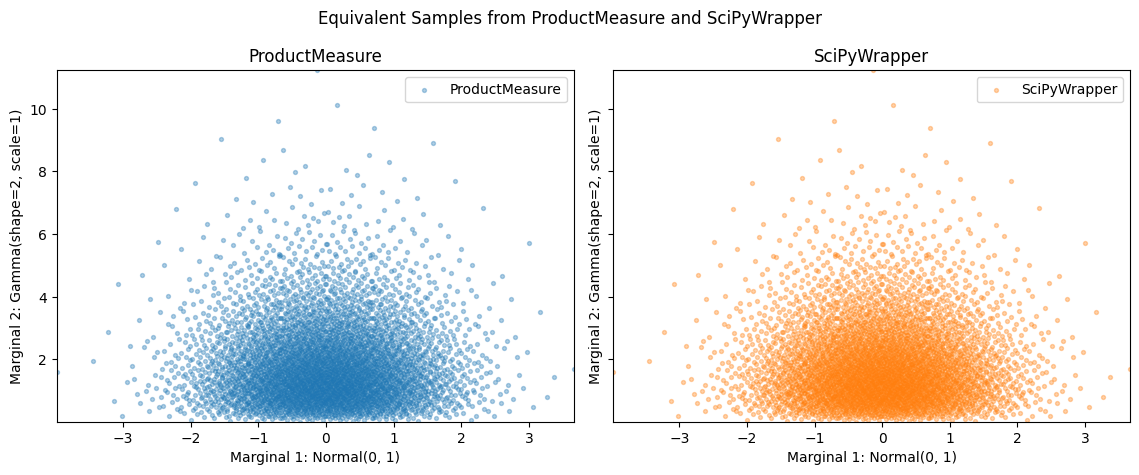

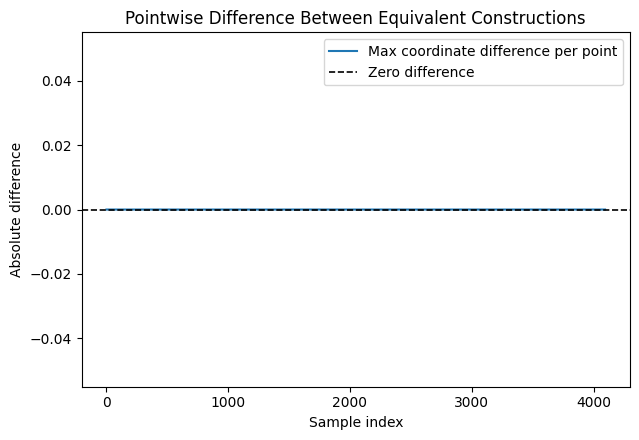

In [6]:
n = 4096
seed = 55
scipy_marginals = [stats.norm(loc=0.0, scale=1.0), stats.gamma(a=2.0, scale=1.0)]
expected_means = np.array([0.0, 2.0])

product_marginals = [
    SciPyWrapper(DummySampler(1), scipy_marginals[0]),
    SciPyWrapper(DummySampler(1), scipy_marginals[1]),
]
product_measure = ProductMeasure(
    sampler=DigitalNetB2(2, seed=seed),
    marginals=product_marginals,
)
single_wrapper = SciPyWrapper(DigitalNetB2(2, seed=seed), scipy_marginals)

product_samples = product_measure(n)
scipy_samples = single_wrapper(n)
difference = product_samples - scipy_samples

product_means = product_samples.mean(axis=0)
scipy_means = scipy_samples.mean(axis=0)
product_corr = np.corrcoef(product_samples.T)[0, 1]
scipy_corr = np.corrcoef(scipy_samples.T)[0, 1]

print("ProductMeasure sample shape:", product_samples.shape)
print("SciPyWrapper sample shape:", scipy_samples.shape)
print(f"Maximum absolute difference: {np.max(np.abs(difference)):.3e}")
print(f"Mean absolute difference: {np.mean(np.abs(difference)):.3e}")
print("Arrays exactly equal:", np.array_equal(product_samples, scipy_samples))
print()
print("Metric                    ProductMeasure    SciPyWrapper    Expected")
print(f"Mean of marginal 1        {product_means[0]:>14.6f}    {scipy_means[0]:>12.6f}    {expected_means[0]:>8.6f}")
print(f"Mean of marginal 2        {product_means[1]:>14.6f}    {scipy_means[1]:>12.6f}    {expected_means[1]:>8.6f}")
print(f"Correlation               {product_corr:>14.6f}    {scipy_corr:>12.6f}    {0.0:>8.6f}")

assert product_samples.shape == scipy_samples.shape == (n, 2)
assert np.array_equal(product_samples, scipy_samples)

x_limits = (
    min(product_samples[:, 0].min(), scipy_samples[:, 0].min()),
    max(product_samples[:, 0].max(), scipy_samples[:, 0].max()),
)
y_limits = (
    min(product_samples[:, 1].min(), scipy_samples[:, 1].min()),
    max(product_samples[:, 1].max(), scipy_samples[:, 1].max()),
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharex=True, sharey=True)
axes[0].scatter(product_samples[:, 0], product_samples[:, 1], s=8, alpha=0.35, label="ProductMeasure")
axes[0].set_title("ProductMeasure")
axes[0].set_xlabel("Marginal 1: Normal(0, 1)")
axes[0].set_ylabel("Marginal 2: Gamma(shape=2, scale=1)")
axes[0].set_xlim(x_limits)
axes[0].set_ylim(y_limits)
axes[0].legend(loc="best")

axes[1].scatter(scipy_samples[:, 0], scipy_samples[:, 1], s=8, alpha=0.35, color="C1", label="SciPyWrapper")
axes[1].set_title("SciPyWrapper")
axes[1].set_xlabel("Marginal 1: Normal(0, 1)")
axes[1].set_ylabel("Marginal 2: Gamma(shape=2, scale=1)")
axes[1].set_xlim(x_limits)
axes[1].set_ylim(y_limits)
axes[1].legend(loc="best")

fig.suptitle("Equivalent Samples from ProductMeasure and SciPyWrapper")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(np.abs(difference).max(axis=1), linewidth=1.5, label="Max coordinate difference per point")
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.2, label="Zero difference")
ax.set_xlabel("Sample index")
ax.set_ylabel("Absolute difference")
ax.set_title("Pointwise Difference Between Equivalent Constructions")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

Both objects use outer samplers with the same seed, receive the same unit-cube points, and apply equivalent marginal inverse-CDF transformations. The exact array equality and zero maximum difference confirm that the ProductMeasure construction matches the combined SciPyWrapper construction here. The side-by-side plots look identical for the same reason.

## Example 6: Validation errors

**What is being tested?** We intentionally pass invalid inputs to `ProductMeasure`.

**Expected result.** Each invalid input should raise a clear exception before sampling starts.

**Why it matters.** These checks protect against ambiguous product measures: empty marginal lists, non-true-measure marginals, and mismatched outer sampler dimension.

In [7]:
def show_expected_error(description, expected_exception, function):
    try:
        function()
    except expected_exception as error:
        print(f"Test: {description}")
        print(f"Exception: {type(error).__name__}")
        print(f"Message: {error}")
        print("Result: PASSED")
        print()
    else:
        raise AssertionError(f"{description}: expected {expected_exception.__name__}")

show_expected_error(
    "Empty marginal list",
    ParameterError,
    lambda: ProductMeasure(sampler=DigitalNetB2(1, seed=7), marginals=[]),
)

show_expected_error(
    "Non-AbstractTrueMeasure marginal",
    ParameterError,
    lambda: ProductMeasure(sampler=DigitalNetB2(1, seed=7), marginals=[object()]),
)

show_expected_error(
    "Outer sampler dimension does not equal sum of marginal dimensions",
    DimensionError,
    lambda: ProductMeasure(
        sampler=DigitalNetB2(2, seed=7),
        marginals=[Uniform(DummySampler(1))],
    ),
)

Test: Empty marginal list
Exception: ParameterError
Message: ProductMeasure requires a nonempty list of marginals.
Result: PASSED

Test: Non-AbstractTrueMeasure marginal
Exception: ParameterError
Message: Each ProductMeasure marginal must be an AbstractTrueMeasure instance.
Result: PASSED

Test: Outer sampler dimension does not equal sum of marginal dimensions
Exception: DimensionError
Message: ProductMeasure sampler dimension must equal the sum of marginal dimensions (2 != 1).
Result: PASSED



The validation errors show that ProductMeasure refuses inputs that would make the coordinate split undefined or mathematically inconsistent.

## What the examples verify

1. `ProductMeasure` combines one-dimensional and multidimensional marginals.
2. The total dimension equals the sum of marginal dimensions.
3. Only the outer sampler generates QMC points.
4. `DummySampler` returns no points and serves only as a construction placeholder.
5. Outer-sampler replications are preserved with shape `(replications, n, total_dimension)`.
6. Sample ranges, means, zero proportions, and Gaussian dependence agree with theoretical expectations.
7. `ProductMeasure` matches an equivalent `SciPyWrapper` construction when both use the same outer sampler seed.
8. Invalid inputs produce clear exceptions before sampling starts.

More general chained transformations for importance sampling are a separate design issue and are not addressed by `ProductMeasure`.